# LSTM Model

Daily next-day electricity consumption forecasting for multiple NMIs. This notebook currently covers data preparation through creation of 3D LSTM input sequences.

## 1. Imports and settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

RANDOM_SEED = 123
LOOKBACK = 30

np.random.seed(RANDOM_SEED)

## 2. Load data

In [2]:
DATA_PATH = Path("nmi_daily_preprocessing.csv")
DATE_COLUMN = "date"
NMI_COLUMN = "NMI"
TARGET_COLUMN = "daily_consumption_raw"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH, dtype={NMI_COLUMN: "string"}, low_memory=False)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")
print("Columns:", df.columns.tolist())
df.head()

Loaded 415,380 rows and 29 columns.
Columns: ['NMI', 'date', 'building_type', 'building_type_group', 'building_type_count', 'dayofweek', 'month', 'quarter', 'is_weekend', 'trend_days', 'maxtemp', 'mintemp', 'avgtemp', 'temp_range', 'rainfall', 'rain_flag', 'has_solar', 'solar_meter_count_selected', 'solar_radiation_available', 'daily_solar_generation_observed', 'lag_1_day', 'lag_7_day', 'hdd', 'cdd', 'daily_consumption_raw', 'half_hour_reading_count', 'half_hour_zero_count', 'daily_complete_48', 'model_ready_weather_lag']


,NMI,date,building_type,building_type_group,building_type_count,dayofweek,month,quarter,is_weekend,trend_days,...,daily_solar_generation_observed,lag_1_day,lag_7_day,hdd,cdd,daily_consumption_raw,half_hour_reading_count,half_hour_zero_count,daily_complete_48,model_ready_weather_lag
0,6102000812,2013-01-01,Unknown,Unknown,0,1,1,1,0,0,...,NaN,NaN,NaN,NaN,NaN,974.544,48,0,True,False
1,6102000812,2013-01-02,Unknown,Unknown,0,2,1,1,0,1,...,NaN,974.544,NaN,NaN,NaN,1131.152,48,0,True,False
2,6102000812,2013-01-03,Unknown,Unknown,0,3,1,1,0,2,...,NaN,1131.152,NaN,NaN,NaN,1418.752,48,0,True,False
3,6102000812,2013-01-04,Unknown,Unknown,0,4,1,1,0,3,...,NaN,1418.752,NaN,NaN,NaN,1671.390,48,0,True,False
4,6102000812,2013-01-05,Unknown,Unknown,0,5,1,1,1,4,...,NaN,1671.390,NaN,NaN,NaN,1136.448,48,0,True,False


## 3. Data preparation

The model inputs below use historical consumption together with the available weather, calendar, building, and solar-status variables. Data-quality fields and `daily_solar_generation_observed` are not model inputs.

In [3]:
# Features to be put in the model. These are the columns that will be used to predict the target variable.
continuous_features = [
    TARGET_COLUMN,
    "maxtemp",
    "mintemp",
    "avgtemp",
    "rainfall",
    "hdd",
    "cdd",
    "daily_solar_generation_observed",
    "lag_1_day",
    "lag_7_day"
]

calendar_features = [
    "dayofweek",
    "month",
    "quarter",
]

binary_features = [
    "is_weekend",
]

categorical_features = [
    "building_type_count"
]

# Check that all required columns are present in the dataframe
required_columns = {
    DATE_COLUMN, NMI_COLUMN, TARGET_COLUMN,
    *categorical_features, *continuous_features, *calendar_features, *binary_features
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Required columns are missing: {sorted(missing_columns)}")

# Convert the date column to datetime and sort the dataframe by NMI and date
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="raise")
df = df.sort_values([NMI_COLUMN, DATE_COLUMN]).reset_index(drop=True)

columns_needed = [
    NMI_COLUMN, DATE_COLUMN, *categorical_features, *continuous_features,
    *calendar_features, *binary_features
]
#if df[columns_needed].isna().any().any():
    #raise ValueError("Null values remain in the selected modelling columns.")
if df.duplicated([NMI_COLUMN, DATE_COLUMN]).any():
    raise ValueError("Duplicate NMI/date rows were found.")

# Cyclical encoding keeps the end and start of each calendar cycle close together.
df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)
df["quarter_sin"] = np.sin(2 * np.pi * (df["quarter"] - 1) / 4)
df["quarter_cos"] = np.cos(2 * np.pi * (df["quarter"] - 1) / 4)

cyclic_feature_columns = [
    "dayofweek_sin", "dayofweek_cos",
    "month_sin", "month_cos",
    "quarter_sin", "quarter_cos",
]

print(f"NMIs: {df[NMI_COLUMN].nunique():,}")
print(f"Date range: {df[DATE_COLUMN].min().date()} to {df[DATE_COLUMN].max().date()}")
print("Continuous features to scale:", continuous_features)
print("Categorical features to one-hot encode:", categorical_features)
print("Cyclical calendar features:", cyclic_feature_columns)
print("Binary features kept unchanged:", binary_features)

NMIs: 86
Date range: 2013-01-01 to 2026-03-23
Continuous features to scale: ['daily_consumption_raw', 'maxtemp', 'mintemp', 'avgtemp', 'rainfall', 'hdd', 'cdd', 'daily_solar_generation_observed', 'lag_1_day', 'lag_7_day']
Categorical features to one-hot encode: ['building_type_count']
Cyclical calendar features: ['dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos']
Binary features kept unchanged: ['is_weekend']


## 4. Train / validation / test split

Dates are split using the manually selected start and end dates below. The ranges are inclusive, rows are never shuffled, and the same boundaries apply to every NMI. Rows outside the three selected periods are excluded.

In [4]:
TRAIN_START_DATE = "2014-01-01"
TRAIN_END_DATE = "2019-12-31"

VALIDATION_START_DATE = "2022-01-01"
VALIDATION_END_DATE = "2023-12-31"

TEST_START_DATE = "2024-01-01"
TEST_END_DATE = "2025-12-31"

train_start = pd.Timestamp(TRAIN_START_DATE)
train_end = pd.Timestamp(TRAIN_END_DATE)
validation_start = pd.Timestamp(VALIDATION_START_DATE)
validation_end = pd.Timestamp(VALIDATION_END_DATE)
test_start = pd.Timestamp(TEST_START_DATE)
test_end = pd.Timestamp(TEST_END_DATE)

if not (
    train_start <= train_end
    < validation_start <= validation_end
    < test_start <= test_end
):
    raise ValueError(
        "Date ranges must be ordered: train, then validation, then test."
    )

train_mask = df[DATE_COLUMN].between(train_start, train_end, inclusive="both")
validation_mask = df[DATE_COLUMN].between(validation_start, validation_end, inclusive="both")
test_mask = df[DATE_COLUMN].between(test_start, test_end, inclusive="both")

# Keep only rows in one of the manually selected periods.
df = df.loc[train_mask | validation_mask | test_mask].copy()
df["split"] = np.select(
    [
        df[DATE_COLUMN].between(train_start, train_end, inclusive="both"),
        df[DATE_COLUMN].between(validation_start, validation_end, inclusive="both"),
    ],
    ["train", "validation"],
    default="test",
)

train_df = df.loc[df["split"] == "train"].copy()
validation_df = df.loc[df["split"] == "validation"].copy()
test_df = df.loc[df["split"] == "test"].copy()

if train_df[DATE_COLUMN].nunique() <= LOOKBACK:
    raise ValueError("The selected training period must be longer than LOOKBACK.")
if validation_df.empty or test_df.empty:
    raise ValueError("The selected validation and test periods must not be empty.")

print(f"Train:      {train_df[DATE_COLUMN].min().date()} to {train_df[DATE_COLUMN].max().date()} ({len(train_df):,} rows)")
print(f"Validation: {validation_df[DATE_COLUMN].min().date()} to {validation_df[DATE_COLUMN].max().date()} ({len(validation_df):,} rows)")
print(f"Test:       {test_df[DATE_COLUMN].min().date()} to {test_df[DATE_COLUMN].max().date()} ({len(test_df):,} rows)")

Train:      2014-01-01 to 2019-12-31 (188,426 rows)
Validation: 2022-01-01 to 2023-12-31 (62,780 rows)
Test:       2024-01-01 to 2025-12-31 (62,866 rows)


## 5. Scaling

Continuous variables are standardized, categorical variables are one-hot encoded, cyclical calendar columns are kept in their sine/cosine form, and binary columns are kept unchanged. The scaler and encoder are fitted on training rows only. A separate target scaler allows later predictions to be converted back to electricity-consumption units.

In [5]:
continuous_scaler = StandardScaler()
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
target_scaler = StandardScaler()

# Fit preprocessing objects only on training data to prevent information leakage.
continuous_scaler.fit(train_df[continuous_features])
onehot_encoder.fit(train_df[categorical_features])
target_scaler.fit(train_df[[TARGET_COLUMN]])

scaled_continuous_columns = [f"scaled__{column}" for column in continuous_features]
df[scaled_continuous_columns] = continuous_scaler.transform(df[continuous_features])

onehot_feature_columns = onehot_encoder.get_feature_names_out(categorical_features).tolist()
df[onehot_feature_columns] = onehot_encoder.transform(df[categorical_features])

df["target_scaled"] = target_scaler.transform(df[[TARGET_COLUMN]]).ravel()

model_feature_columns = (
    scaled_continuous_columns
    + onehot_feature_columns
    + cyclic_feature_columns
    + binary_features
)

print("Continuous scaler and one-hot encoder fitted on training data only.")
print(f"Final number of LSTM input features: {len(model_feature_columns)}")
print("Final input features:", model_feature_columns)

Continuous scaler and one-hot encoder fitted on training data only.
Final number of LSTM input features: 22
Final input features: ['scaled__daily_consumption_raw', 'scaled__maxtemp', 'scaled__mintemp', 'scaled__avgtemp', 'scaled__rainfall', 'scaled__hdd', 'scaled__cdd', 'scaled__daily_solar_generation_observed', 'scaled__lag_1_day', 'scaled__lag_7_day', 'building_type_count_0', 'building_type_count_1', 'building_type_count_2', 'building_type_count_3', 'building_type_count_4', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'is_weekend']


## 6. Sequence creation

Each sequence contains `LOOKBACK` consecutive days from one NMI and predicts that NMI's consumption on the next day. With `LOOKBACK = 30`:

- Day 1–30 → Day 31
- Day 2–31 → Day 32

Sequences are built separately for each NMI and each uninterrupted daily block. Therefore, a sequence cannot cross an NMI boundary or a gap in the dates. Validation and test targets can use earlier observed days as context, which is appropriate for next-day evaluation.

In [6]:
def create_sequences(data, input_columns, lookback):
    X_sequences = []
    y_sequences = []
    sequence_splits = []
    sequence_nmis = []
    target_dates = []

    for nmi, nmi_data in data.groupby(NMI_COLUMN, sort=False):
        nmi_data = nmi_data.sort_values(DATE_COLUMN).copy()

        # Never let a sequence cross a gap in this NMI's daily history.
        new_block = nmi_data[DATE_COLUMN].diff().ne(pd.Timedelta(days=1))
        nmi_data["contiguous_block"] = new_block.cumsum()

        for _, block in nmi_data.groupby("contiguous_block", sort=False):
            block = block.reset_index(drop=True)
            feature_values = block[input_columns].to_numpy(dtype=np.float32)
            target_values = block["target_scaled"].to_numpy(dtype=np.float32)

            for target_index in range(lookback, len(block)):
                window_start = target_index - lookback

                # Temporary handling for the older dataset version.
                if (
                    not np.isfinite(feature_values[window_start:target_index]).all()
                    or not np.isfinite(target_values[target_index])
                ):
                    continue

                X_sequences.append(feature_values[window_start:target_index])
                y_sequences.append(target_values[target_index])
                sequence_splits.append(block.loc[target_index, "split"])
                sequence_nmis.append(nmi)
                target_dates.append(block.loc[target_index, DATE_COLUMN])

    if not X_sequences:
        raise ValueError("No sequences were created. Reduce LOOKBACK or inspect the data.")

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
        np.asarray(sequence_splits),
        np.asarray(sequence_nmis),
        np.asarray(target_dates),
    )

X_all, y_all, sequence_splits, sequence_nmis, target_dates = create_sequences(
    data=df,
    input_columns=model_feature_columns,
    lookback=LOOKBACK,
)

train_mask = sequence_splits == "train"
validation_mask = sequence_splits == "validation"
test_mask = sequence_splits == "test"

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_validation, y_validation = X_all[validation_mask], y_all[validation_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Train X shape: {X_train.shape}; y shape: {y_train.shape}")
print(f"Validation X shape: {X_validation.shape}; y shape: {y_validation.shape}")
print(f"Test X shape: {X_test.shape}; y shape: {y_test.shape}")

Train X shape: (63928, 30, 22); y shape: (63928,)
Validation X shape: (25699, 30, 22); y shape: (25699,)
Test X shape: (25934, 30, 22); y shape: (25934,)


## 7. Build the LSTM model

This first model is intentionally small: one built-in Keras LSTM layer followed by one regression output. Dropout is applied inside the LSTM to provide light regularization without adding network depth.

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

LSTM_UNITS = 64
DROPOUT = 0.0
LEARNING_RATE = 0.001
BATCH_SIZE = 256
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=X_train.shape[1:]),
    tf.keras.layers.LSTM(LSTM_UNITS, dropout=DROPOUT),
    tf.keras.layers.Dense(1),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,337 (87.25 KB)

 Trainable params: 22,337 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the model

Training uses only the training sequences. Validation sequences control early stopping and the final test period remains untouched until assessment.

In [8]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=0.001,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1,
)

epochs_completed = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_validation_loss = float(np.min(history.history["val_loss"]))

print(f"Training stopped after epoch {epochs_completed}.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.6f}")

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.1754 - val_loss: 0.0466
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0299 - val_loss: 0.0337
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0213 - val_loss: 0.0194
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0188 - val_loss: 0.0234
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0207 - val_loss: 0.0245
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0189 - val_loss: 0.0183
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.0154 - val_loss: 0.0189
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0149 - val_loss: 0.0220
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0155 - val_loss: 0.0205
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0144 - val_loss: 0.0144
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.0127 - val_loss: 0.0125
Epoch 12/30
250/250 ━━━━━━━━━━━━━━━━━━━━

## 9. Training diagnostics

The loss curves show whether the model converged and whether validation performance began to deteriorate while training loss continued to improve.

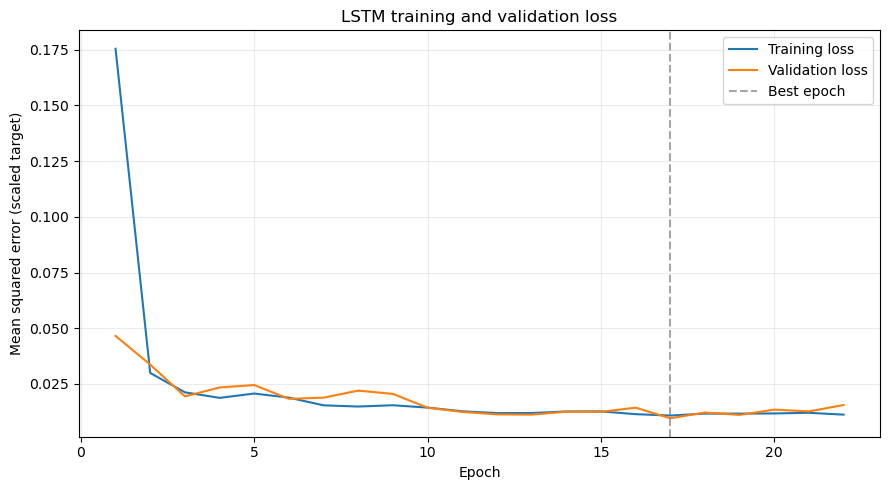

In [9]:
plt.figure(figsize=(9, 5))
epochs = range(1, len(history.history["loss"]) + 1)
plt.plot(epochs, history.history["loss"], label="Training loss")
plt.plot(epochs, history.history["val_loss"], label="Validation loss")
plt.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7, label="Best epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error (scaled target)")
plt.title("LSTM training and validation loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Model assessment

Validation and test predictions are converted from the scaled target back to the original daily-consumption units. The result table retains the NMI, target date, actual value, prediction, and split for every assessed sequence.

In [10]:
def inverse_target(values):
    values = np.asarray(values).reshape(-1, 1)
    return target_scaler.inverse_transform(values).ravel()


def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "WAPE": np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual)) * 100
    }


test_predictions_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()

test_results = pd.DataFrame({
    NMI_COLUMN: sequence_nmis[test_mask],
    "target_date": pd.to_datetime(target_dates[test_mask]),
    "actual_consumption": inverse_target(y_test),
    "predicted_consumption": inverse_target(test_predictions_scaled),
    "split": "test",
})

test_results["year"] = test_results["target_date"].dt.year

levels = {
    "Per-NMI daily": test_results,
    "Per-NMI yearly": test_results.groupby(
        [NMI_COLUMN, "year"], as_index=False
    )[["actual_consumption", "predicted_consumption"]].sum(),
    "Total-site daily": test_results.groupby(
        "target_date", as_index=False
    )[["actual_consumption", "predicted_consumption"]].sum(),
    "Total-site yearly": test_results.groupby(
        "year", as_index=False
    )[["actual_consumption", "predicted_consumption"]].sum(),
}

assessment_metrics = pd.DataFrame([
    {"split": "test", **regression_metrics(
        test_results["actual_consumption"],
        test_results["predicted_consumption"],
    )},
])
assessment_metrics = pd.DataFrame([
    {"level": level,
        **regression_metrics(
            data["actual_consumption"],
            data["predicted_consumption"],
        ),
    }
    for level, data in levels.items()
])

display(assessment_metrics.round(3))
display(test_results.head())



,level,MAE,RMSE,WAPE
0,Per-NMI daily,376.020,546.293,10.252
1,Per-NMI yearly,44361.086,52250.368,3.451
2,Total-site daily,8573.896,11033.476,6.589
3,Total-site yearly,1469296.000,1473162.271,3.089


,NMI,target_date,actual_consumption,predicted_consumption,split,year
0,6102002302,2024-01-01,276.319946,862.611206,test,2024
1,6102002302,2024-01-02,799.079956,1085.302124,test,2024
2,6102002302,2024-01-03,885.680054,1156.497681,test,2024
3,6102002302,2024-01-04,764.799927,1114.604370,test,2024
4,6102002302,2024-01-05,684.719849,1173.743042,test,2024


## 11. Simple baseline comparison

The lag-1 benchmark predicts that each NMI will consume the same amount as on its previous observed day. It is compared with the LSTM on exactly the same test rows for which lag-1 is available.

In [11]:
lag_1_lookup = df[[NMI_COLUMN, DATE_COLUMN, "lag_1_day"]].rename(
    columns={DATE_COLUMN: "target_date", "lag_1_day": "lag_1_prediction"}
)

test_comparison = test_results.merge(
    lag_1_lookup,
    on=[NMI_COLUMN, "target_date"],
    how="left",
    validate="one_to_one",
)
test_comparison = test_comparison.loc[
    np.isfinite(test_comparison["lag_1_prediction"])
].copy()

baseline_comparison = pd.DataFrame([
    {"model": "LSTM", **regression_metrics(
        test_comparison["actual_consumption"],
        test_comparison["predicted_consumption"],
    )},
    {"model": "Lag-1 baseline", **regression_metrics(
        test_comparison["actual_consumption"],
        test_comparison["lag_1_prediction"],
    )},
])

display(baseline_comparison.round(3))

,model,MAE,RMSE,WAPE
0,LSTM,376.020,546.293,10.252
1,Lag-1 baseline,392.031,723.150,10.689


## 12. Hyperparameter tuning plan

Tuning will be staged to control computation: first compare lookbacks, then tune LSTM units using the best lookback, and finally tune dropout using the best preceding choices. Each candidate uses expanding-window validation: fold 1 trains on all observations before its validation block; later folds add earlier validation blocks to training. The final test period is excluded from every fold and must be used only once after selection.

In [ ]:
TUNING_LOOKBACKS = [14, 30, 60]
TUNING_LSTM_UNITS = [32, 64, 128]
TUNING_DROPOUTS = [0.0, 0.1, 0.2]
NUMBER_OF_TIME_FOLDS = 3

tuning_stages = pd.DataFrame({
    "stage": [1, 2, 3],
    "parameter": ["LOOKBACK", "LSTM units", "dropout"],
    "values": [TUNING_LOOKBACKS, TUNING_LSTM_UNITS, TUNING_DROPOUTS],
})


def create_expanding_validation_folds(data, number_of_folds=3):
    tuning_data = data.loc[data["split"] != "test"].copy()
    validation_dates = np.sort(
        tuning_data.loc[tuning_data["split"] == "validation", DATE_COLUMN].unique()
    )
    date_blocks = np.array_split(validation_dates, number_of_folds)
    folds = []

    for fold_number, validation_block in enumerate(date_blocks, start=1):
        if len(validation_block) == 0:
            continue
        fold_validation_start = pd.Timestamp(validation_block[0])
        fold_validation_end = pd.Timestamp(validation_block[-1])
        fold_train = tuning_data[DATE_COLUMN] < fold_validation_start
        fold_validation = tuning_data[DATE_COLUMN].between(
            fold_validation_start, fold_validation_end, inclusive="both"
        )
        folds.append({
            "fold": fold_number,
            "train_mask": fold_train.to_numpy(),
            "validation_mask": fold_validation.to_numpy(),
            "train_end": tuning_data.loc[fold_train, DATE_COLUMN].max(),
            "validation_start": fold_validation_start,
            "validation_end": fold_validation_end,
        })

    return tuning_data, folds


tuning_data, expanding_folds = create_expanding_validation_folds(
    df, NUMBER_OF_TIME_FOLDS
)
fold_summary = pd.DataFrame([
    {
        "fold": fold["fold"],
        "train_end": fold["train_end"],
        "validation_start": fold["validation_start"],
        "validation_end": fold["validation_end"],
    }
    for fold in expanding_folds
])

display(tuning_stages)
display(fold_summary)
print("No tuning search has been launched. The final test period is excluded.")

,stage,parameter,values
0,1,LOOKBACK,"[14, 30, 60]"
1,2,LSTM units,"[32, 64, 128]"
2,3,dropout,"[0.0, 0.2, 0.3]"


,fold,train_end,validation_start,validation_end
0,1,2020-12-31,2023-01-01,2023-09-01
1,2,2023-09-01,2023-09-02,2024-05-02
2,3,2024-05-02,2024-05-03,2024-12-31


No tuning search has been launched. The final test period is excluded.


## 13. Long-horizon backtest setup

A recursive backtest starts from one historical forecast origin and repeatedly feeds predicted consumption back into the history. Actual future consumption is retained only for scoring and is never supplied as an input. The example uses recorded future explanatory variables as a retrospective scenario; a production backtest should substitute archived weather forecasts when available.

In [67]:
future_explanatory_columns = (
    [NMI_COLUMN, DATE_COLUMN]
    + [
        column for column in continuous_features
        if column not in {TARGET_COLUMN, "lag_1_day", "lag_7_day"}
    ]
    + categorical_features
)


def transform_rows_for_lstm(rows):
    transformed = rows.copy()
    transformed["dayofweek_sin"] = np.sin(
        2 * np.pi * transformed[DATE_COLUMN].dt.dayofweek / 7
    )
    transformed["dayofweek_cos"] = np.cos(
        2 * np.pi * transformed[DATE_COLUMN].dt.dayofweek / 7
    )
    transformed["month_sin"] = np.sin(
        2 * np.pi * (transformed[DATE_COLUMN].dt.month - 1) / 12
    )
    transformed["month_cos"] = np.cos(
        2 * np.pi * (transformed[DATE_COLUMN].dt.month - 1) / 12
    )
    transformed["quarter_sin"] = np.sin(
        2 * np.pi * (transformed[DATE_COLUMN].dt.quarter - 1) / 4
    )
    transformed["quarter_cos"] = np.cos(
        2 * np.pi * (transformed[DATE_COLUMN].dt.quarter - 1) / 4
    )
    transformed["is_weekend"] = (
        transformed[DATE_COLUMN].dt.dayofweek >= 5
    ).astype(int)
    transformed[scaled_continuous_columns] = continuous_scaler.transform(
        transformed[continuous_features]
    )
    transformed[onehot_feature_columns] = onehot_encoder.transform(
        transformed[categorical_features]
    )
    return transformed[model_feature_columns].to_numpy(dtype=np.float32)


def recursive_forecast_nmi(trained_model, history_data, future_data, lookback):
    history = history_data.sort_values(DATE_COLUMN).tail(lookback).copy()
    future = future_data.sort_values(DATE_COLUMN).copy()
    forecasts = []

    if len(history) < lookback:
        raise ValueError("The NMI needs at least LOOKBACK historical rows.")
    if history[NMI_COLUMN].nunique() != 1 or future[NMI_COLUMN].nunique() != 1:
        raise ValueError("Forecast one NMI at a time.")
    if history[NMI_COLUMN].iloc[0] != future[NMI_COLUMN].iloc[0]:
        raise ValueError("History and future data must belong to the same NMI.")

    for _, future_row in future.iterrows():
        expected_date = history[DATE_COLUMN].iloc[-1] + pd.Timedelta(days=1)
        if future_row[DATE_COLUMN] != expected_date:
            raise ValueError("History and future scenario must contain consecutive dates.")

        X_window = transform_rows_for_lstm(history.tail(lookback))
        if not np.isfinite(X_window).all():
            raise ValueError("Non-finite values were found in a recursive input window.")

        prediction_scaled = trained_model(
            X_window[np.newaxis, ...], training=False
        ).numpy().ravel()[0]
        prediction = inverse_target([prediction_scaled])[0]

        new_history_row = future_row.copy()
        new_history_row[TARGET_COLUMN] = prediction
        new_history_row["lag_1_day"] = history[TARGET_COLUMN].iloc[-1]
        new_history_row["lag_7_day"] = history[TARGET_COLUMN].iloc[-7]
        history = pd.concat(
            [history, new_history_row.to_frame().T], ignore_index=True
        )
        history[DATE_COLUMN] = pd.to_datetime(history[DATE_COLUMN])
        forecasts.append({
            NMI_COLUMN: future_row[NMI_COLUMN],
            "target_date": future_row[DATE_COLUMN],
            "predicted_consumption": prediction,
        })

    return pd.DataFrame(forecasts)


RUN_BACKTEST_EXAMPLE = False

if RUN_BACKTEST_EXAMPLE:
    first_validation_index = np.flatnonzero(validation_mask)[0]
    example_nmi = sequence_nmis[first_validation_index]
    example_origin = pd.Timestamp(target_dates[first_validation_index])
    example_end = min(example_origin + pd.Timedelta(days=729), validation_end)

    example_history = df.loc[
        (df[NMI_COLUMN] == example_nmi) & (df[DATE_COLUMN] < example_origin)
    ].tail(LOOKBACK)
    example_actuals = df.loc[
        (df[NMI_COLUMN] == example_nmi)
        & df[DATE_COLUMN].between(example_origin, example_end, inclusive="both")
    ].copy()
    example_future = example_actuals[future_explanatory_columns].copy()

    backtest_results = recursive_forecast_nmi(
        model, example_history, example_future, LOOKBACK
    ).merge(
        example_actuals[[NMI_COLUMN, DATE_COLUMN, TARGET_COLUMN]].rename(
            columns={DATE_COLUMN: "target_date", TARGET_COLUMN: "actual_consumption"}
        ),
        on=[NMI_COLUMN, "target_date"],
        validate="one_to_one",
    )
    print(regression_metrics(
        backtest_results["actual_consumption"],
        backtest_results["predicted_consumption"],
    ))
else:
    print("Recursive backtest function is ready. Set RUN_BACKTEST_EXAMPLE=True to run one NMI.")

Recursive backtest function is ready. Set RUN_BACKTEST_EXAMPLE=True to run one NMI.


## 14. Final two-year forecasting preparation

No future weather is fabricated here. The final forecast requires an externally supplied daily explanatory-variable scenario for every NMI. After validation, that scenario can be passed NMI-by-NMI to `recursive_forecast_nmi`, which will generate target and lag values recursively.

In [68]:
FINAL_FORECAST_HORIZON_DAYS = 730


def validate_future_explanatory_data(future_data, expected_nmis, horizon_days=730):
    missing_columns = set(future_explanatory_columns).difference(future_data.columns)
    if missing_columns:
        raise KeyError(f"Future scenario is missing columns: {sorted(missing_columns)}")

    future = future_data[future_explanatory_columns].copy()
    future[DATE_COLUMN] = pd.to_datetime(future[DATE_COLUMN], errors="raise")
    if future.isna().any().any():
        raise ValueError("Future explanatory data contains missing values.")
    if future.duplicated([NMI_COLUMN, DATE_COLUMN]).any():
        raise ValueError("Future explanatory data contains duplicate NMI/date rows.")

    supplied_nmis = set(future[NMI_COLUMN].astype(str).unique())
    expected_nmis = set(pd.Series(expected_nmis, dtype="string").astype(str))
    if supplied_nmis != expected_nmis:
        raise ValueError("Future scenario NMIs do not match the expected NMI set.")

    rows_per_nmi = future.groupby(NMI_COLUMN).size()
    if not rows_per_nmi.eq(horizon_days).all():
        raise ValueError(f"Each NMI must contain exactly {horizon_days} future days.")

    daily_gaps = (
        future.sort_values([NMI_COLUMN, DATE_COLUMN])
        .groupby(NMI_COLUMN)[DATE_COLUMN]
        .diff()
        .dropna()
    )
    if not daily_gaps.eq(pd.Timedelta(days=1)).all():
        raise ValueError("Future scenario dates must be consecutive within each NMI.")

    return future.sort_values([NMI_COLUMN, DATE_COLUMN]).reset_index(drop=True)


print("Required future scenario columns:")
print(future_explanatory_columns)
print(f"Required horizon per NMI: {FINAL_FORECAST_HORIZON_DAYS} daily rows")

Required future scenario columns:
['NMI', 'date', 'maxtemp', 'mintemp', 'avgtemp', 'rainfall', 'hdd', 'cdd', 'daily_solar_generation_observed', 'building_type_count']
Required horizon per NMI: 730 daily rows
